cos:  1.0
q = 0.1962
D = 3153486080.315348
[(0.0, 0.0), (20.12987012987013, 0.0), (40.25974025974026, 0.0), (60.38961038961039, 0.0), (80.51948051948052, 0.0), (100.64935064935064, 0.0), (120.77922077922078, 0.0), (140.9090909090909, 0.0), (161.03896103896105, 0.0), (181.16883116883116, 0.0), (201.29870129870127, 0.0), (221.42857142857142, 0.0), (241.55844155844156, 0.0), (261.68831168831167, 0.0), (281.8181818181818, 0.0), (301.94805194805195, 0.0), (322.0779220779221, 0.0), (342.2077922077922, 0.0), (362.3376623376623, 0.0), (382.46753246753246, 0.0), (402.59740259740255, 0.0), (422.7272727272727, 0.0), (442.85714285714283, 0.0), (462.987012987013, 0.0), (483.1168831168831, 0.0), (503.24675324675326, 0.0), (523.3766233766233, 0.0), (543.5064935064935, 0.0), (563.6363636363636, 0.0), (583.7662337662338, 0.0), (603.8961038961039, 0.0), (624.025974025974, 0.0), (644.1558441558442, 0.0), (664.2857142857142, 0.0), (684.4155844155844, 0.0), (704.5454545454545, 0.0), (724.6753246753246, 0.0

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

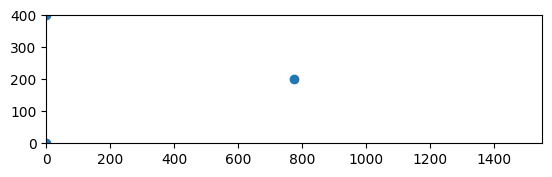

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Objects': {'Vectors': False…

In [ ]:
from ngsolve import *
from netgen.geom2d import SplineGeometry
import netgen.gui
import numpy as np
from ngsolve.webgui import Draw
import matplotlib.pyplot as plt
from ngsolve import x,y
from netgen.occ import *
from math import pi, cos
from ngsolve.fem import NODE_TYPE
from ngsolve.meshes import MakeStructured2DMesh


#PUNKT RAND/AUFLAGER
def ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,AuflagerListe,scale=1,step=40,maxh=0.08,Neigungsfaktor_cos=1):
    #region PARAMETER (MILLIMETER)
    E  = 70e6
    nu = 0.23
    rho = 2.5e-6
    g = 9810

    q = rho*t*g * Neigungsfaktor_cos

    D = E*t**3/(12*(1-nu**2))      # Biegesteifigkeit
    G = E/(2*(1+nu))
    ks = 5/6                       # Schubkorrektur
    S = ks*G*t                     # Schubsteifigkeit
    A = E*t/(1-nu**2)              # Membransteifigkeit

    print("q =", q)
    print("D =", D)
    #endregion

    #region GEOMETRIE
    # shape = MoveTo(0,0).Rectangle(Lx,Ly).Face()
    # shape.edges.name="free"
    # rect = shape 
    # geo = OCCGeometry(rect,dim=2)
    # mesh = Mesh(geo.GenerateMesh(maxh=maxh))

    mesh = MakeStructured2DMesh(
        quads=False,
        nx=int(Lx/maxh),        # kommt aufs selbe heraus, wie GenerateMesh, nur dass Muster anders aussieht
        ny=int(Ly/maxh),
        mapping=lambda x, y: (Lx*x,Ly*y)
    )
    mesh.Curve(3)
    # Draw(mesh)
    #endregion

    #region FEM-Räume
    order = 2
    Vw = H1(mesh, order=order)      # Durchbiegung
    Vb = VectorH1(mesh, order=order)    # Rotation

    X = FESpace([Vw, Vb])

    u, beta = X.TrialFunction()
    v, eta  = X.TestFunction()

    gf = GridFunction(X)
    w, rot = gf.components
    #endregion
    
    #region FEM
    def eps_bending(b):
        return Sym(Grad(b))

    def inner_sym(A,B):
        return InnerProduct(A,B)

    a = BilinearForm(X, symmetric=True)
    # Biegung
    a += D * (
        (1-nu)*inner_sym(eps_bending(beta), eps_bending(eta))
        + nu*Trace(eps_bending(beta))*Trace(eps_bending(eta))
    ) * dx
    # Schub: grad(w)-beta
    a += S * InnerProduct(Grad(u)-beta, Grad(v)-eta) * dx

    f = LinearForm(X)
    f += -q * v * dx

    a.Assemble()
    f.Assemble()

    import numpy as np
    # Nearest_Vertex_ID Liste basteln
    meshPunkte = mesh.vertices      # holen uns die Menge aller Punkte aus unserem Mesh
    anzahl_auflager = len(AuflagerListe)
    Nearest_Vertex_ID = np.zeros(anzahl_auflager)       # speichert jeweils für alle AuflagerPunkte den nächsten meshPunkt
    for i,punkt in enumerate(AuflagerListe):
        distances = [np.linalg.norm( np.array(mPunkt.point) - punkt ) for mPunkt in meshPunkte]
        print([mPunkt.point for mPunkt in meshPunkte])
        vertexNr = np.argmin(distances)
        Nearest_Vertex_ID[i] = vertexNr

    free_dofs = X.FreeDofs()        # holt alle Freiheitsgrade
    for vertexNummer in Nearest_Vertex_ID.astype(int):
        for dof in Vw.GetDofNrs(NodeId(NODE_TYPE.VERTEX, vertexNummer)):
            free_dofs[dof] = False

    gf.vec[:] = 0
    # gfu.vec.data = a.mat.Inverse(free_dofs) * f.vec
    gf.vec[:] = a.mat.Inverse(freedofs=X.FreeDofs()) * f.vec
    # Draw(w, mesh,euler_angles=[-60,-10,-20], deformation=True, scale=scale);

    print("maxh:",maxh)
    print("min w [mm] =", min(w.vec.FV().NumPy()))
    print("Scale in Visualization: ",scale)

    Draw(w,mesh,deformation=True,euler_angles=[-60,5,30],scale=scale)
    #endregion

    #region PLOTTEN
    import numpy as np
    #erzeugt gitter für gewünschte werte
    # x_points = np.round(np.linspace(0,l, step)).astype(int)
    # y_points = np.round(np.linspace(0,b, step)).astype(int)
    x_points_ungerundet = np.linspace(0,Lx, step)
    x_points = np.round(x_points_ungerundet, 2)
    y_points_ungerundet = np.linspace(0,Ly, step)
    y_points = np.round(y_points_ungerundet, 2)
    # print(x_points_ungerundet)
    # print(x_points)

    X_mesh, Y_mesh = np.meshgrid(x_points, y_points)
    #print(x_points)
    #speichert (x,y,z) in gravitation_matrix für alle (x,y) in X_mesh,Y_mesh
    gravitation_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            try:
                z_eintrag = w(X_mesh[i, j], Y_mesh[i, j])
            except:
                z_eintrag = 0
            gravitation_matrix[i, j] = (float(X_mesh[i,j]), float(Y_mesh[i,j]), z_eintrag)

    #*.xyz file erstellen
    filename_GRAV = f"xyzFiles/{t}mm_gravitation.xyz"
    with open(filename_GRAV, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, z_w = gravitation_matrix[i, j]
                f.write(f"{x:.2f}\t{y:.2f}\t{z_w:.2f}\n")

    import matplotlib.pyplot as plt

    xs = [x[0] for x in supports]
    ys = [x[1] for x in supports]
    plt.scatter(xs, ys)
    plt.xlim(0, Lx)
    plt.ylim(0, Ly)

    plt.gca().set_aspect('equal', adjustable='box')  # optional: gleiche Skalierung
    plt.show()
    #endregion

    Draw(w, mesh,deformation=True,euler_angles=[-60,5,30],settings={'Objects': {'Vectors': False, 'Wireframe': False, 'Surface': True}},scale=scale)
    return filename_GRAV


if __name__ =='__main__':
    Lx = 1550
    Ly = 400
    t  = 8               # Dicke
    step = 40           # Anzahl gespeicherter Punkte in x/y-Richtung im xyz-File

    # supports = [(0.4,0.1),(1.15,0.1),(0.4,0.3),(1.15,0.3)]
    # supports = [(0.875,0.1),(0.675,0.1),(0.875,0.3),(0.675,0.3)]
    scale = 100        # für den NGSolve-Plot
    maxh = 20           # die Dichtheit des Mesh    

    Neigungswinkel_grad = 0 # Gradz
    Neigungswinkel_rad = Neigungswinkel_grad * pi/180
    Neigungsfaktor_cos = cos(Neigungswinkel_rad)
    print("cos: ",Neigungsfaktor_cos)

    #KANTEN-AUFLAGER
    # kanten_supports = [(2/10*Lx,Ly*8/10), (8/10*Lx,Ly*8/10)]
    # ReissnerMindlin_GRAV_Kante(Lx,Ly,t,kanten_supports,scale,step,maxh,Neigungsfaktor_cos)

    #PUNKT-AUFLAGER
    dosen_radius = 25 #mm
    # supports = [(dosen_radius,dosen_radius), (dosen_radius,Ly-dosen_radius), (Lx-dosen_radius,dosen_radius), (Lx-dosen_radius,Ly-dosen_radius)] # supports1
    # supports = [(Lx/2 - dosen_radius,0),(Lx/2 - dosen_radius,Ly), (Lx/2 + dosen_radius,0),(Lx/2 + dosen_radius,Ly)] # supports2
    # supports = [(Lx/2 - 3*dosen_radius,0),(Lx/2 - 3*dosen_radius,Ly), (Lx/2 + 3*dosen_radius,0),(Lx/2 + 3*dosen_radius,Ly)]       # supports3
    # supports = [(0,0),(0,Ly),(Lx/2,Ly/2)]

    # supports = [(0,0),(0,Ly),(Lx,0),(Lx,Ly)]
    # supports = [(2/10*Lx,Ly*8/10), (8/10*Lx,Ly*8/10), (2/10*Lx,Ly*2/10),(8/10*Lx,Ly*2/10)]
    ReissnerMindlin_GRAV_Punkte(Lx,Ly,t,supports,scale,step,maxh,Neigungsfaktor_cos)

